<center>

# Bioinformática Avanzada 2025
## TP Nº6: Procesamiento y Análisis Bioinformático de datos de Secuenciación Masiva
### Cálculo de métricas de archivos SAM/BAM a partir de Samtools

Daniela Rodríguez Golpe


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

Datos cargados. Graficando 1677 posiciones para 'chr1'...
¡Gráfico guardado exitosamente como 'grafico_profundidad.png'!


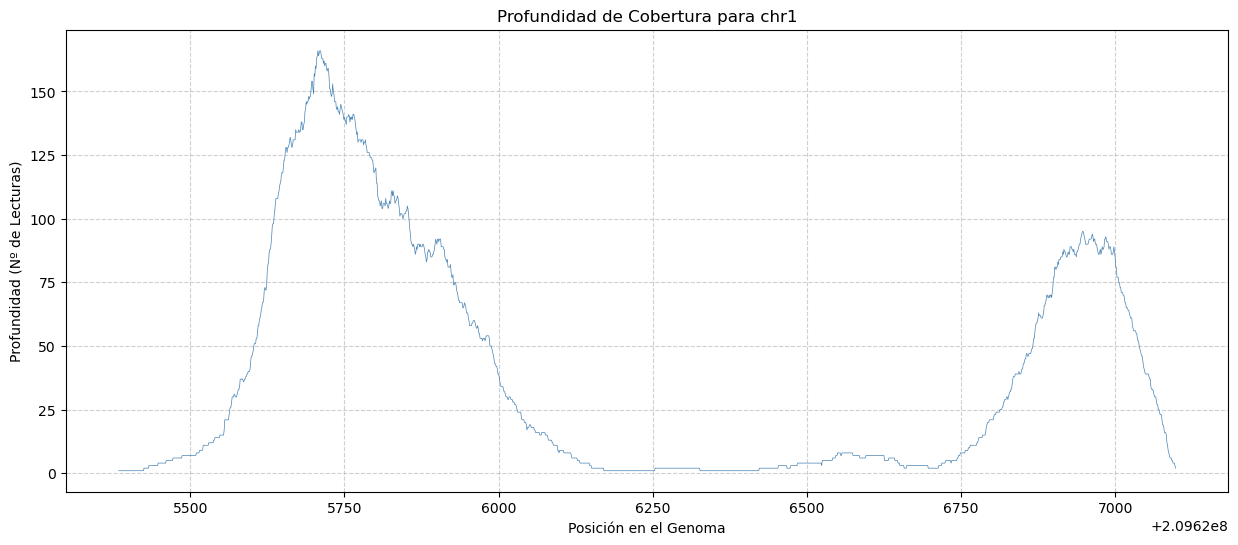

In [2]:
# Configuración 
archivo_profundidad = 'profundidad.txt'
contig_a_graficar = 'chr1'  # Nombre de la referencia
archivo_salida_png = 'grafico_profundidad.png'

# Definir los nombres de las columnas para pandas
nombres_columnas = ['referencia', 'posicion', 'profundidad']

# Leer el archivo de profundidad
try:
    df = pd.read_csv(archivo_profundidad, sep='\t', header=None, names=nombres_columnas)
except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{archivo_profundidad}'")
    exit()

# Filtrar solo el contig/referencia que queremos graficar
df_contig = df[df['referencia'] == contig_a_graficar]

if df_contig.empty:
    print(f"Error: No se encontraron datos para la referencia '{contig_a_graficar}'")
    print(f"Asegúrate de que el nombre coincide. Referencias encontradas: {df['referencia'].unique()}")
else:
    print(f"Datos cargados. Graficando {len(df_contig)} posiciones para '{contig_a_graficar}'...")
    
    # Crear el gráfico
    plt.figure(figsize=(15, 6)) # Tamaño de la figura (ancho, alto)
    plt.plot(df_contig['posicion'], df_contig['profundidad'], 
             color='steelblue', linewidth=0.5)
    
    # Añadir títulos y etiquetas
    plt.title(f'Profundidad de Cobertura para {contig_a_graficar}')
    plt.xlabel('Posición en el Genoma')
    plt.ylabel('Profundidad (Nº de Lecturas)')
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Guardar el gráfico en un archivo
    plt.savefig(archivo_salida_png)
    
    print(f"¡Gráfico guardado exitosamente como '{archivo_salida_png}'!")

El archivo profundidad.txt que creamos con samtools depth tiene una particularidad: por defecto, solo informa las posiciones que SÍ tienen cobertura (profundidad > 0).

Si calculamos el promedio de ese archivo, obtendremos la "profundidad promedio de las zonas cubiertas", pero no la "profundidad promedio de todo el genoma". Las posiciones con profundidad 0 no estarían en el cálculo, y eso inflaría artificialmente el promedio.

Para calcular el promedio y el desvío estándar correctos sobre todo el genoma, necesitamos pedirle a samtools que nos dé todas las posiciones, incluyendo las que tienen profundidad 0.
Ahora que tenemos el archivo correcto (profundidad_completa.txt), podemos usar pandas para los cálculos.


In [2]:
#Script calcular.stats.py

# Nombre del archivo a analizar
archivo_entrada = 'profundidad_completa.txt'

print(f"Cargando el archivo '{archivo_entrada}'... (Esto puede tardar un momento)")

try:
    # Cargamos el archivo en pandas
    df = pd.read_csv(
        archivo_entrada, 
        sep='\t', 
        header=None, 
        names=['referencia', 'posicion', 'profundidad']
    )
except FileNotFoundError:
    print(f"Error: No se encontró el archivo '{archivo_entrada}'")
    print("Asegúrate de haber ejecutado 'samtools depth -a ...' primero.")
    sys.exit(1)

# Seleccionar solo la columna 'profundidad'
columna_profundidad = df['profundidad']

# Calcular las métricas
promedio = columna_profundidad.mean()
desvio_estandar = columna_profundidad.std()

# También se puede obtener otros datos útiles
prof_maxima = columna_profundidad.max()
prof_minima = columna_profundidad.min()
total_posiciones = len(columna_profundidad)

# Imprimimos los resultados
print("\n--- Métricas de Profundidad (Basado en el genoma completo) ---")
print(f"Total de posiciones analizadas: {total_posiciones}")
print(f"Profundidad Promedio:           {promedio:.2f}")
print(f"Desvío Estándar:               {desvio_estandar:.2f}")
print(f"Profundidad Máxima:             {prof_maxima}")
print(f"Profundidad Mínima:             {prof_minima}")
print("----------------------------------------------------------")

Cargando el archivo 'profundidad_completa.txt'... (Esto puede tardar un momento)

--- Métricas de Profundidad (Basado en el genoma completo) ---
Total de posiciones analizadas: 125842308
Profundidad Promedio:           0.00
Desvío Estándar:               0.00
Profundidad Máxima:             0.0
Profundidad Mínima:             0.0
----------------------------------------------------------


El reporte flagstat muestra que solo hay 772 lecturas en total en el archivo BAM. Aunque el 100% de ellas se alinearon correctamente , son una cantidad infinitesimal para cubrir un genoma de 125 millones de posiciones por eso las métricas de profundidad dan cercanas a 0

In [3]:
# Cobertura (en %) del genoma target para un dado umbral de profundidad.
archivo_datos = 'solo_posiciones_cubiertas.txt'
tamano_genoma = 125842308  
umbrales = [1, 5, 10, 20, 50]  # Lista de umbrales que quieres evaluar (X)

try:
    print(f"Cargando '{archivo_datos}'...")
    # Leemos solo la columna de profundidad (la 3ra, índice 2) para ahorrar memoria
    df = pd.read_csv(archivo_datos, sep='\t', header=None, usecols=[2], names=['Profundidad'])

    print("\n--- Resultados de Cobertura ---")
    print(f"Tamaño del genoma base: {tamano_genoma:,} pb")
    print(f"Posiciones totales con datos (>0X): {len(df):,}\n")

    print(f"{'Umbral (>=)':<12} | {'Posiciones cubiertas':<22} | {'Cobertura (%)':<15}")
    print("-" * 55)

    for umbral in umbrales:
        # Cuenta cuántas posiciones superan el umbral
        num_posiciones = (df['Profundidad'] >= umbral).sum()
        # Calcula el porcentaje
        porcentaje = (num_posiciones / tamano_genoma) * 100
        
        print(f"{umbral:<11}X | {num_posiciones:<22,} | {porcentaje:.6f}%")

    print("-" * 55)

except FileNotFoundError:
    print(f"ERROR: No se encontró '{archivo_datos}'.")
except Exception as e:
    print(f"Ocurrió un error: {e}")

Cargando 'solo_posiciones_cubiertas.txt'...

--- Resultados de Cobertura ---
Tamaño del genoma base: 125,842,308 pb
Posiciones totales con datos (>0X): 1,677

Umbral (>=)  | Posiciones cubiertas   | Cobertura (%)  
-------------------------------------------------------
1          X | 1,677                  | 0.001333%
5          X | 1,162                  | 0.000923%
10         X | 899                    | 0.000714%
20         X | 773                    | 0.000614%
50         X | 559                    | 0.000444%
-------------------------------------------------------
